# Inference: 30-Class Fruit Classifier (FIDS30)

Evaluate the trained model on the test set with confusion matrix and classification report.

In [7]:
import torch
import timm
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Setup Model
NUM_CLASSES = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("fids30_classifier_30cls_b0.pth", map_location=device))
model = model.to(device)
model.eval()

# 2. Setup Test Data
config = timm.data.resolve_model_data_config(model)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_ds)}")
print(f"Classes: {test_ds.classes}")

Test samples: 195
Classes: ['acerolas', 'apples', 'apricots', 'avocados', 'bananas', 'blackberries', 'blueberries', 'cantaloupes', 'cherries', 'coconuts', 'figs', 'grapefruits', 'grapes', 'guava', 'kiwifruit', 'lemons', 'limes', 'mangos', 'olives', 'oranges', 'passionfruit', 'peaches', 'pears', 'pineapples', 'plums', 'pomegranates', 'raspberries', 'strawberries', 'tomatoes', 'watermelons']


In [8]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Classification Report
target_names = test_ds.classes
print("Test Set Performance:")
print(classification_report(all_labels, all_preds, target_names=target_names))

Test Set Performance:
              precision    recall  f1-score   support

    acerolas       0.50      0.60      0.55         5
      apples       0.75      0.75      0.75         8
    apricots       0.36      0.67      0.47         6
    avocados       0.80      0.80      0.80         5
     bananas       0.90      1.00      0.95         9
blackberries       1.00      0.88      0.93         8
 blueberries       0.62      0.83      0.71         6
 cantaloupes       1.00      0.83      0.91         6
    cherries       0.60      0.50      0.55         6
    coconuts       1.00      1.00      1.00         5
        figs       0.71      1.00      0.83         5
 grapefruits       1.00      0.50      0.67         6
      grapes       0.78      0.88      0.82         8
       guava       1.00      0.67      0.80         6
   kiwifruit       1.00      1.00      1.00         7
      lemons       0.50      0.83      0.62         6
       limes       0.80      0.67      0.73         6
     

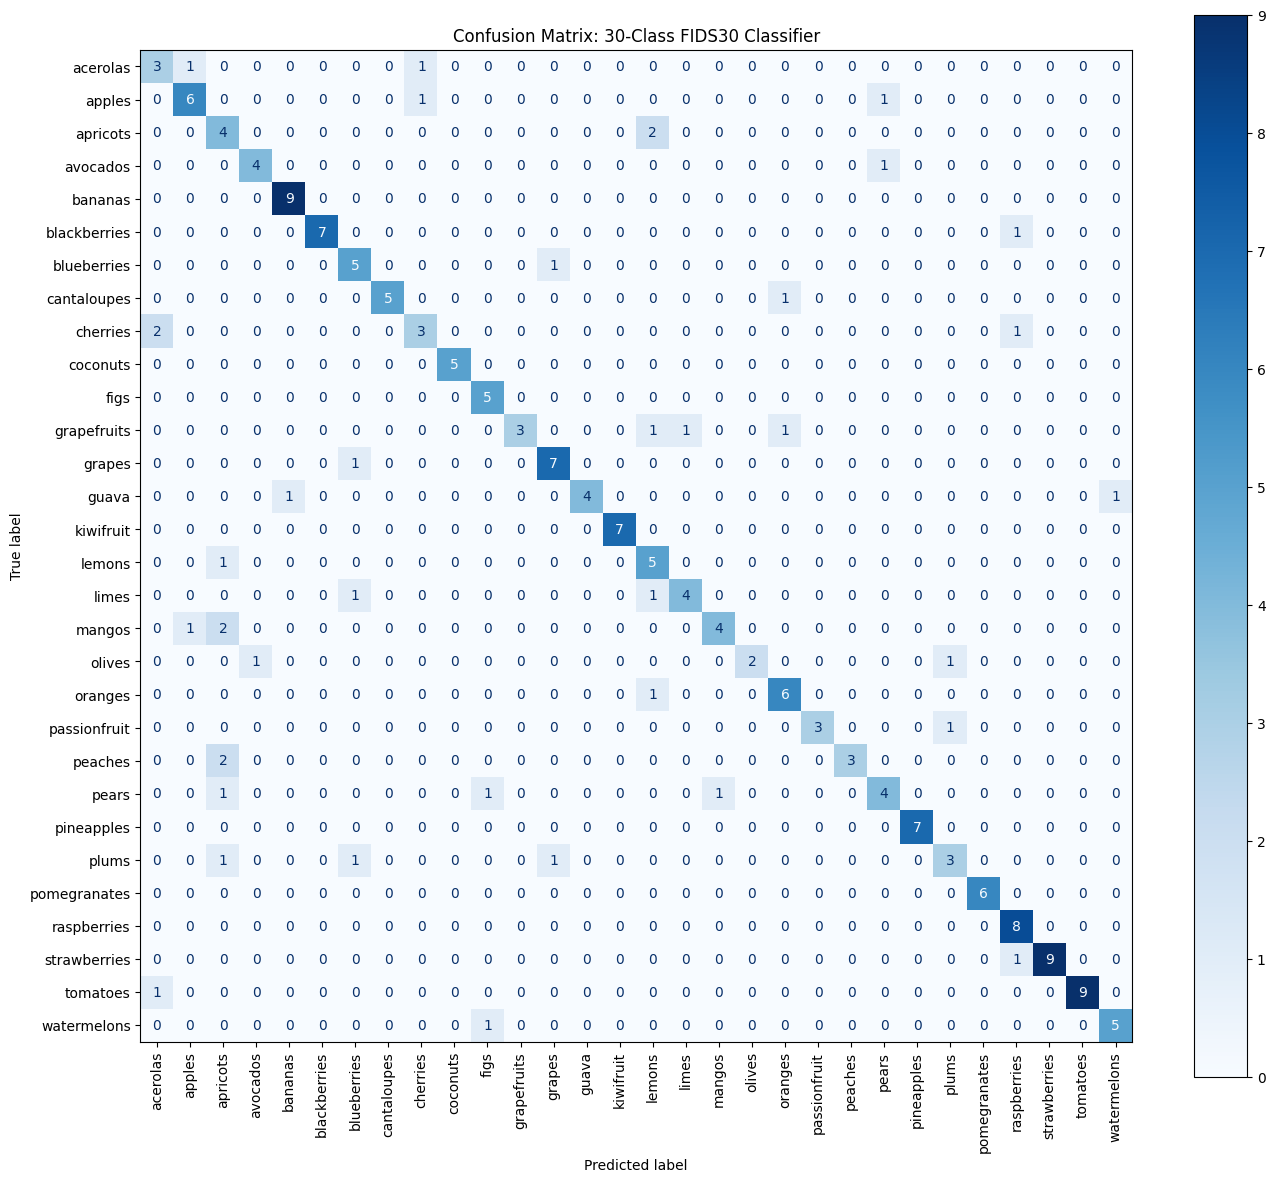

In [9]:
# 4. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix: 30-Class FIDS30 Classifier")
plt.tight_layout()
plt.show()

## 5. Simulating Class Imbalance: Accuracy vs Balanced Accuracy

Accuracy can be misleading when class sizes are very uneven. To demonstrate this, we create
an imbalanced test set: keep 1 "dominant" class with 50x repeated images, and subsample just
2 images per class from the remaining 29. A dummy classifier that always predicts the dominant
class can score high accuracy, but balanced accuracy (mean of per-class recall) exposes the problem.

In [10]:
import os
import shutil
import random
from pathlib import Path
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

random.seed(42)

SOURCE_TEST = Path("PrepData/Test")
IMBALANCED_TEST = Path("PrepData/Test_Imbalanced")

# Pick 1 dominant class (10x duplicated), rest get only 2 images each
all_classes = sorted([d.name for d in SOURCE_TEST.iterdir() if d.is_dir()])
DOMINANT_CLASS = all_classes[0]  # first alphabetically
DOMINANT_REPEAT = 50  # repeat dominant class images 50x
MINORITY_SAMPLE = 2

print(f"Dominant class (images repeated {DOMINANT_REPEAT}x): {DOMINANT_CLASS}")
print(f"Minority classes ({len(all_classes) - 1}): {MINORITY_SAMPLE} images each")

# Build imbalanced test set via symlinks
if IMBALANCED_TEST.exists():
    shutil.rmtree(IMBALANCED_TEST)

for cls_name in all_classes:
    src_dir = SOURCE_TEST / cls_name
    dest_dir = IMBALANCED_TEST / cls_name
    dest_dir.mkdir(parents=True, exist_ok=True)

    imgs = sorted([p for p in src_dir.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

    if cls_name == DOMINANT_CLASS:
        # Symlink each image 10 times with unique names
        for repeat in range(DOMINANT_REPEAT):
            for img_path in imgs:
                link_name = f"{img_path.stem}_r{repeat}{img_path.suffix}"
                os.symlink(img_path.resolve(), dest_dir / link_name)
        total = len(imgs) * DOMINANT_REPEAT
    else:
        selected = random.sample(imgs, min(MINORITY_SAMPLE, len(imgs)))
        for img_path in selected:
            os.symlink(img_path.resolve(), dest_dir / img_path.name)
        total = len(selected)

    print(f"  {cls_name}: {total} images{'  <- dominant (50x)' if cls_name == DOMINANT_CLASS else ''}")

Dominant class (images repeated 50x): acerolas
Minority classes (29): 2 images each
  acerolas: 250 images  <- dominant (50x)
  apples: 2 images
  apricots: 2 images
  avocados: 2 images
  bananas: 2 images
  blackberries: 2 images
  blueberries: 2 images
  cantaloupes: 2 images
  cherries: 2 images
  coconuts: 2 images
  figs: 2 images
  grapefruits: 2 images
  grapes: 2 images
  guava: 2 images
  kiwifruit: 2 images
  lemons: 2 images
  limes: 2 images
  mangos: 2 images
  olives: 2 images
  oranges: 2 images
  passionfruit: 2 images
  peaches: 2 images
  pears: 2 images
  pineapples: 2 images
  plums: 2 images
  pomegranates: 2 images
  raspberries: 2 images
  strawberries: 2 images
  tomatoes: 2 images
  watermelons: 2 images


In [11]:
# Evaluate on the imbalanced test set
imb_ds = datasets.ImageFolder(str(IMBALANCED_TEST), transform=test_transform)
imb_loader = DataLoader(imb_ds, batch_size=32, shuffle=False)

imb_preds = []
imb_labels = []

with torch.no_grad():
    for images, labels in imb_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        imb_preds.extend(preds.cpu().numpy())
        imb_labels.extend(labels.cpu().numpy())

imb_class_names = imb_ds.classes

acc = accuracy_score(imb_labels, imb_preds)
bal_acc = balanced_accuracy_score(imb_labels, imb_preds)

print(f"Imbalanced test set: {len(imb_ds)} samples")
print(f"  Accuracy:          {acc:.2%}")
print(f"  Balanced Accuracy: {bal_acc:.2%}")
print(f"\nAccuracy can be inflated because the dominant class ({DOMINANT_CLASS}) "
      f"contribute most of the samples. Balanced accuracy averages per-class recall, "
      f"giving equal weight to every class regardless of size.")

Imbalanced test set: 308 samples
  Accuracy:          62.99%
  Balanced Accuracy: 75.33%

Accuracy can be inflated because the dominant class (acerolas) contribute most of the samples. Balanced accuracy averages per-class recall, giving equal weight to every class regardless of size.


In [12]:
# Side-by-side comparison: real model vs dummy classifier
from sklearn.metrics import classification_report

# Per-class recall on imbalanced set (real model)
imb_report = classification_report(imb_labels, imb_preds, target_names=imb_class_names,
                                    output_dict=True)
per_class_recall = {cls: imb_report[cls]["recall"] for cls in imb_class_names}

# Dummy classifier: always predicts the most frequent class in the imbalanced set
most_frequent_class = max(set(imb_labels), key=imb_labels.count)
dummy_preds = [most_frequent_class] * len(imb_labels)

dummy_acc = accuracy_score(imb_labels, dummy_preds)
dummy_bal_acc = balanced_accuracy_score(imb_labels, dummy_preds)

print("=== Real Model ===")
print(f"  Accuracy:          {acc:.2%}")
print(f"  Balanced Accuracy: {bal_acc:.2%}")
print(f"\n=== Dummy Classifier (always predicts '{imb_class_names[most_frequent_class]}') ===")
print(f"  Accuracy:          {dummy_acc:.2%}")
print(f"  Balanced Accuracy: {dummy_bal_acc:.2%}")
print(f"\nThe dummy gets {dummy_acc:.0%} accuracy by just guessing the dominant class, "
      f"but balanced accuracy reveals it at {dummy_bal_acc:.0%}.")

=== Real Model ===
  Accuracy:          62.99%
  Balanced Accuracy: 75.33%

=== Dummy Classifier (always predicts 'acerolas') ===
  Accuracy:          81.17%
  Balanced Accuracy: 3.33%

The dummy gets 81% accuracy by just guessing the dominant class, but balanced accuracy reveals it at 3%.


/home/stas/my_git/fh3_GAI4_course/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/stas/my_git/fh3_GAI4_course/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/stas/my_git/fh3_GAI4_course/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

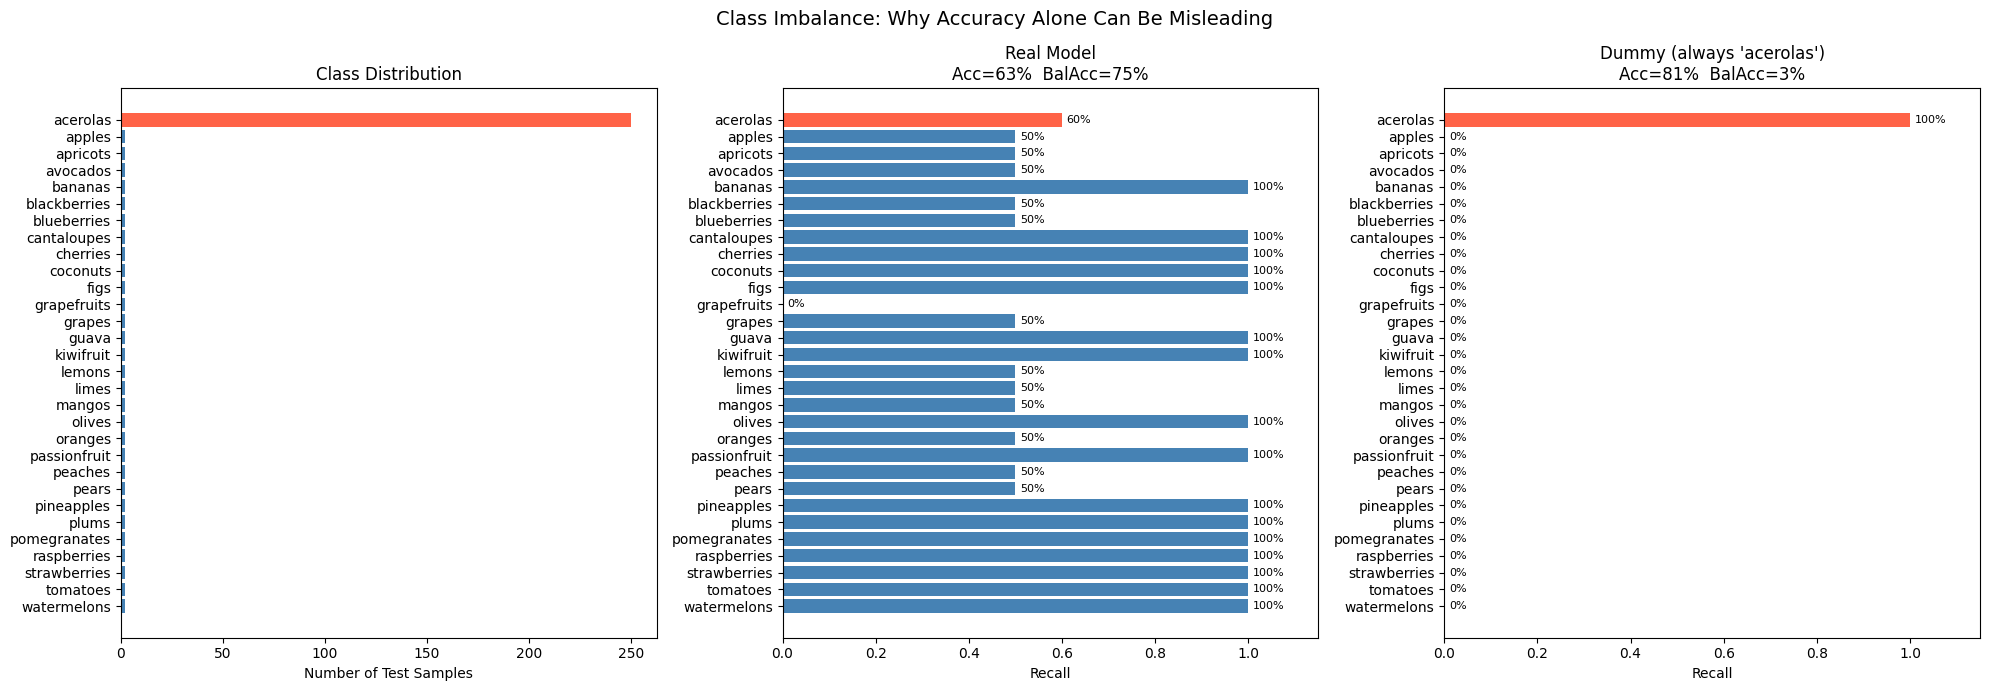

Cleaned up PrepData/Test_Imbalanced


In [13]:
# Visualize: Real Model vs Dummy Classifier
dummy_report = classification_report(imb_labels, dummy_preds, target_names=imb_class_names,
                                      output_dict=True, zero_division=0)
dummy_recall = {cls: dummy_report[cls]["recall"] for cls in imb_class_names}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1. Class distribution
class_counts = [len(list((IMBALANCED_TEST / cls).glob("*"))) for cls in imb_class_names]
colors_dist = ["tomato" if cls == DOMINANT_CLASS else "steelblue" for cls in imb_class_names]
axes[0].barh(imb_class_names, class_counts, color=colors_dist)
axes[0].set_xlabel("Number of Test Samples")
axes[0].set_title("Class Distribution")
axes[0].invert_yaxis()

# 2. Real model per-class recall
recall_vals = [per_class_recall[cls] for cls in imb_class_names]
colors_recall = ["tomato" if cls == DOMINANT_CLASS else "steelblue" for cls in imb_class_names]
bars = axes[1].barh(imb_class_names, recall_vals, color=colors_recall)
for bar, val in zip(bars, recall_vals):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.0%}", va='center', fontsize=8)
axes[1].set_xlabel("Recall")
axes[1].set_xlim(0, 1.15)
axes[1].set_title(f"Real Model\nAcc={acc:.0%}  BalAcc={bal_acc:.0%}")
axes[1].invert_yaxis()

# 3. Dummy classifier per-class recall
dummy_vals = [dummy_recall[cls] for cls in imb_class_names]
colors_dummy = ["tomato" if cls == DOMINANT_CLASS else "steelblue" for cls in imb_class_names]
bars = axes[2].barh(imb_class_names, dummy_vals, color=colors_dummy)
for bar, val in zip(bars, dummy_vals):
    axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.0%}", va='center', fontsize=8)
axes[2].set_xlabel("Recall")
axes[2].set_xlim(0, 1.15)
axes[2].set_title(f"Dummy (always '{imb_class_names[most_frequent_class]}')\nAcc={dummy_acc:.0%}  BalAcc={dummy_bal_acc:.0%}")
axes[2].invert_yaxis()

fig.suptitle("Class Imbalance: Why Accuracy Alone Can Be Misleading", fontsize=14)
plt.tight_layout()
plt.show()

# Cleanup
shutil.rmtree(IMBALANCED_TEST)
print(f"Cleaned up {IMBALANCED_TEST}")